# 02 — Transformer vs CNN Baseline

Load saved checkpoints for the transformer and the DeepMind CNN, run both
on the held-out test split, and compare accuracy, macro-F1, and hit-rate.
Also visualises attention maps to show which residue positions the transformer
attends to most strongly.

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nucb_transformer.utils.io import load_checkpoint
from nucb_transformer.training.metrics import compute_metrics, confusion_matrix_df, hit_rate

from sklearn.metrics import f1_score
from nucb_transformer.training.metrics import (
    ACTIVITY_CLASSES, hit_rate, bootstrap_hit_rate, spearman_rho, confusion_matrix_df,
)
import numpy as np

from nucb_transformer.data.encoding import tokenize

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from nucb_cnn.utils.io import load_checkpoint as cnn_load_checkpoint



In [2]:
# to resolve issue w kernel launching from wrong directory(?)
import os
os.chdir('/Users/zahmiriajohnson/repo/AwasthiJohnson_10.C51')

In [ ]:
# # Reconstruct transformer from best checkpoint
# model_trans, ckpt_trans = load_checkpoint('checkpoints/training_trans/epoch_046_acc0.6746.pt')
# print('Saved transformer val metrics:', ckpt_trans.get('metrics', {}))

# # Reconstruct cnn from best checkpoint
# model_cnn, ckpt_cnn = load_checkpoint('checkpoints/training_cnn/epoch_023_acc0.6700.pt')
# print('Saved CNN val metrics:', ckpt_cnn.get('metrics', {}))

# # Run on test set and compute metrics

In [3]:
# I already did the testing using script/eval....
# and saved the predictions in a csv, so I'll just load that here
cnn_preds_df = pd.read_csv('results/cnn_test_predictions.csv')
trans_preds_df = pd.read_csv('results/trans_test_predictions.csv')

In [4]:
# Def functions to compute metrics for both models
def _to_indices(df):
    labels = np.array([ACTIVITY_CLASSES.index(c) for c in df["activity_level"]])
    preds  = np.array([ACTIVITY_CLASSES.index(c) for c in df["predicted_class"]])
    return preds, labels

def summarize(name, df):
    preds, labels = _to_indices(df)
    accuracy  = float((preds == labels).mean())
    macro_f1  = float(f1_score(labels, preds, average="macro", zero_division=0))
    per_cls   = f1_score(labels, preds, average=None, zero_division=0)
    hr        = hit_rate(preds, labels)
    ci_lo, ci_hi = bootstrap_hit_rate(preds, labels)
    rho       = spearman_rho(preds.astype(float), labels.astype(float))

    print(f"{'='*40}")
    print(f"  {name}  (n={len(df):,})")
    print(f"{'='*40}")
    print(f"  accuracy      {accuracy:.4f}")
    print(f"  macro_f1      {macro_f1:.4f}")
    print(f"  hit_rate      {hr:.4f}  (95% CI: {ci_lo:.4f}–{ci_hi:.4f})")
    print(f"  spearman_rho  {rho:.4f}")
    print()
    for i, cls in enumerate(ACTIVITY_CLASSES):
        print(f"  f1  {cls:<24}  {per_cls[i]:.4f}")
    print()
    print("Confusion matrix (rows=true, cols=predicted):")
    display(confusion_matrix_df(preds, labels))
    print()
    return dict(model=name, accuracy=accuracy, macro_f1=macro_f1,
                hit_rate=hr, spearman_rho=rho)


In [21]:
# Summarize results
rows = [
    summarize("CNN",         cnn_preds_df),
    summarize("Transformer", trans_preds_df),
]

print("--- Summary ---")
display(pd.DataFrame(rows).set_index("model").round(4))

  CNN  (n=42,694)
  accuracy      0.4060
  macro_f1      0.2833
  hit_rate      0.8308  (95% CI: 0.8231–0.8385)
  spearman_rho  0.1989

  f1  activity > 0              0.2511
  f1  activity > A73R           0.0000
  f1  activity > WT             0.4364
  f1  non-functional            0.4457

Confusion matrix (rows=true, cols=predicted):


,activity > 0,activity > A73R,activity > WT,non-functional
activity > 0,1917,0,4834,765
activity > A73R,21,0,166,2
activity > WT,1301,0,7765,291
non-functional,4513,0,13466,7653



  Transformer  (n=42,694)
  accuracy      0.4343
  macro_f1      0.2671
  hit_rate      0.8366  (95% CI: 0.8288–0.8439)
  spearman_rho  0.1333

  f1  activity > 0              0.0814
  f1  activity > A73R           0.0089
  f1  activity > WT             0.4446
  f1  non-functional            0.5335

Confusion matrix (rows=true, cols=predicted):


,activity > 0,activity > A73R,activity > WT,non-functional
activity > 0,426,191,4732,2167
activity > A73R,14,6,158,11
activity > WT,323,268,7554,1212
non-functional,2194,701,12180,10557



--- Summary ---


,accuracy,macro_f1,hit_rate,spearman_rho
model,,,,
CNN,0.4060,0.2833,0.8308,0.1989
Transformer,0.4343,0.2671,0.8366,0.1333


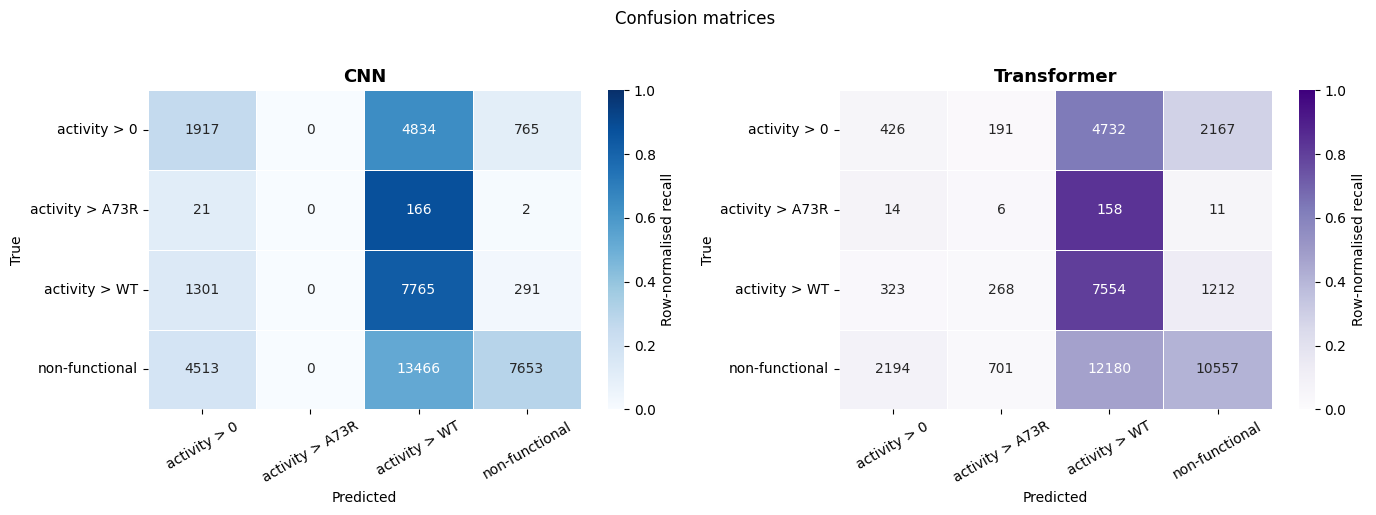

In [5]:
# Confusion matrices (heat maps)
# change order of the classes???
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df, cmap) in zip(axes, [("CNN", cnn_preds_df,"Blues"), ("Transformer", trans_preds_df,"Purples")]):
    preds, labels = _to_indices(df)
    cm = confusion_matrix_df(preds, labels)
    # Normalise rows so each cell shows recall per true class
    cm_norm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(
        cm_norm,
        ax=ax,
        annot=cm.values,       # raw counts in each cell
        fmt="d",
        cmap=cmap,
        vmin=0, vmax=1,
        linewidths=0.5,
        cbar_kws={"label": "Row-normalised recall"},
    )
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Confusion matrices", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices by mutation #?
# from gaurav: fix the following mutation count bins for the
# confusion matrices: 3, 4-5, 6-10, 11-15, 16+



In [6]:
# Color assignment
c_cnn = '#8FB8ED'
c_trans = '#996888'

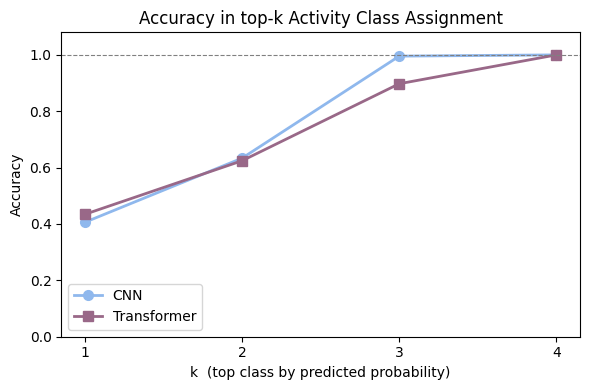

In [7]:
# Top-k accuracy
# could also use sklearn.metrics.top_k_accuracy_score,
# but it doesn't handle ties well
# (e.g. if two classes have same prob,
# it counts as correct if either is true label
# — which can inflate top-2 acc when there are many ties)

prob_cols = [f"prob_{cls}" for cls in ACTIVITY_CLASSES]

def topk_accuracy(df, ks):
    probs  = df[prob_cols].values                          # (N, 4)
    labels = np.array([ACTIVITY_CLASSES.index(c) for c in df["activity_level"]])
    # rank classes by descending probability for each sample
    ranked = np.argsort(-probs, axis=1)                    # (N, 4) — col 0 = top-1 class
    return [float(np.any(ranked[:, :k] == labels[:, None], axis=1).mean()) for k in ks]

ks = list(range(1, len(ACTIVITY_CLASSES) + 1))
cnn_topk   = topk_accuracy(cnn_preds_df,   ks)
trans_topk = topk_accuracy(trans_preds_df, ks)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, cnn_topk,   marker="o", linewidth=2, markersize=7, label="CNN",c=c_cnn)
ax.plot(ks, trans_topk, marker="s", linewidth=2, markersize=7, label="Transformer",c=c_trans)

# for k, acc in zip(ks, cnn_topk):
#     ax.annotate(f"{acc:.3f}", xy=(k, acc), xytext=(-18, 6),
#                 textcoords="offset points", fontsize=8)
# for k, acc in zip(ks, trans_topk):
#     ax.annotate(f"{acc:.3f}", xy=(k, acc), xytext=(4, 6),
#                 textcoords="offset points", fontsize=8)

ax.set_xticks(ks)
#ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_xlabel("k  (top class by predicted probability)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.08)
ax.set_title("Accuracy in top-k Activity Class Assignment", fontsize=12)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
# # Top-1 accuracy curve
# def topk_accuracy_curve(df, n_points=300):
#     probs    = df[prob_cols].values
#     pred_idx = np.array([ACTIVITY_CLASSES.index(c) for c in df["predicted_class"]])
#     true_idx = np.array([ACTIVITY_CLASSES.index(c) for c in df["activity_level"]])

#     confidence  = probs[np.arange(len(df)), pred_idx]
#     order       = np.argsort(-confidence)
#     pred_sorted = pred_idx[order]
#     true_sorted = true_idx[order]

#     n  = len(df)
#     ks = np.unique(np.linspace(1, n, n_points).astype(int))
#     accs = [(pred_sorted[:k] == true_sorted[:k]).mean() for k in ks]
#     return ks / n, np.array(accs)

# frac_cnn,   acc_cnn   = topk_accuracy_curve(cnn_preds_df)
# frac_trans, acc_trans = topk_accuracy_curve(trans_preds_df)

# preds_cnn,   labels_cnn   = _to_indices(cnn_preds_df)
# preds_trans, labels_trans = _to_indices(trans_preds_df)
# overall_acc_cnn   = (preds_cnn   == labels_cnn).mean()
# overall_acc_trans = (preds_trans == labels_trans).mean()

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(frac_cnn[1:-1],   acc_cnn[1:-1],   linewidth=2, label="CNN", c=c_cnn)
# ax.plot(frac_trans[1:-1], acc_trans[1:-1], linewidth=2, label="Transformer", c=c_trans)
# ax.axhline(overall_acc_cnn,   color=c_cnn,   linestyle="--", linewidth=1,
#            label=f"CNN overall ({overall_acc_cnn:.3f})")
# ax.axhline(overall_acc_trans, color=c_trans, linestyle="--", linewidth=1,
#            label=f"Transformer overall ({overall_acc_trans:.3f})")

# ax.set_xlabel("Fraction of test set retained (ranked by prediction confidence)")
# ax.set_ylabel("Top-1 accuracy")
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1.05)
# ax.set_title("Top-1 accuracy vs. confidence threshold", fontsize=12)
# ax.legend()
# plt.tight_layout()
# plt.show()

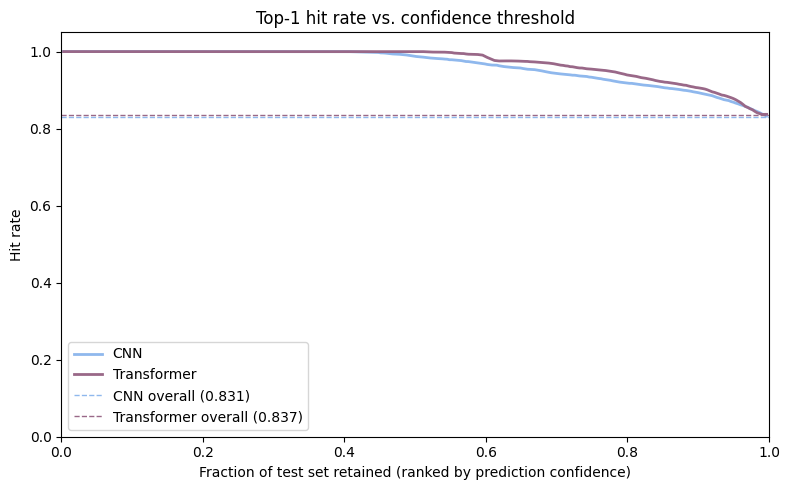

In [ ]:
# Top-1 (hit rate)
def topk_hit_rate_curve(df, n_points=300):
    probs    = df[prob_cols].values
    pred_idx = np.array([ACTIVITY_CLASSES.index(c) for c in df["predicted_class"]])
    true_idx = np.array([ACTIVITY_CLASSES.index(c) for c in df["activity_level"]])

    # confidence = probability the model assigned to its own predicted class
    confidence = probs[np.arange(len(df)), pred_idx]

    # sort sequences from most to least confident
    order       = np.argsort(-confidence)
    pred_sorted = pred_idx[order]
    true_sorted = true_idx[order]

    n  = len(df)
    ks = np.unique(np.linspace(1, n, n_points).astype(int))
    rates = [hit_rate(pred_sorted[:k], true_sorted[:k]) for k in ks]
    return ks / n, np.array(rates)

frac_cnn,   hr_cnn   = topk_hit_rate_curve(cnn_preds_df)
frac_trans, hr_trans = topk_hit_rate_curve(trans_preds_df)

# overall hit rate computed directly — no argument reversal
preds_cnn,   labels_cnn   = _to_indices(cnn_preds_df)
preds_trans, labels_trans = _to_indices(trans_preds_df)
overall_hr_cnn   = hit_rate(preds_cnn,   labels_cnn)
overall_hr_trans = hit_rate(preds_trans, labels_trans)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frac_cnn[1:-1],   hr_cnn[1:-1],   linewidth=2, label="CNN", c=c_cnn)
ax.plot(frac_trans[1:-1], hr_trans[1:-1], linewidth=2, label="Transformer", c=c_trans)
ax.axhline(overall_hr_cnn,   color=c_cnn, linestyle="--", linewidth=1,
           label=f"CNN overall ({overall_hr_cnn:.3f})")
ax.axhline(overall_hr_trans, color=c_trans, linestyle="--", linewidth=1,
           label=f"Transformer overall ({overall_hr_trans:.3f})")

ax.set_xlabel("Fraction of test set retained (ranked by prediction confidence)")
ax.set_ylabel("Hit rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title("Top-1 hit rate vs. confidence threshold", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

Extracting transformer embeddings…
Extracting CNN embeddings…
Running PCA + t-SNE…


/Users/zahmiriajohnson/opt/miniconda3/envs/nucb_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


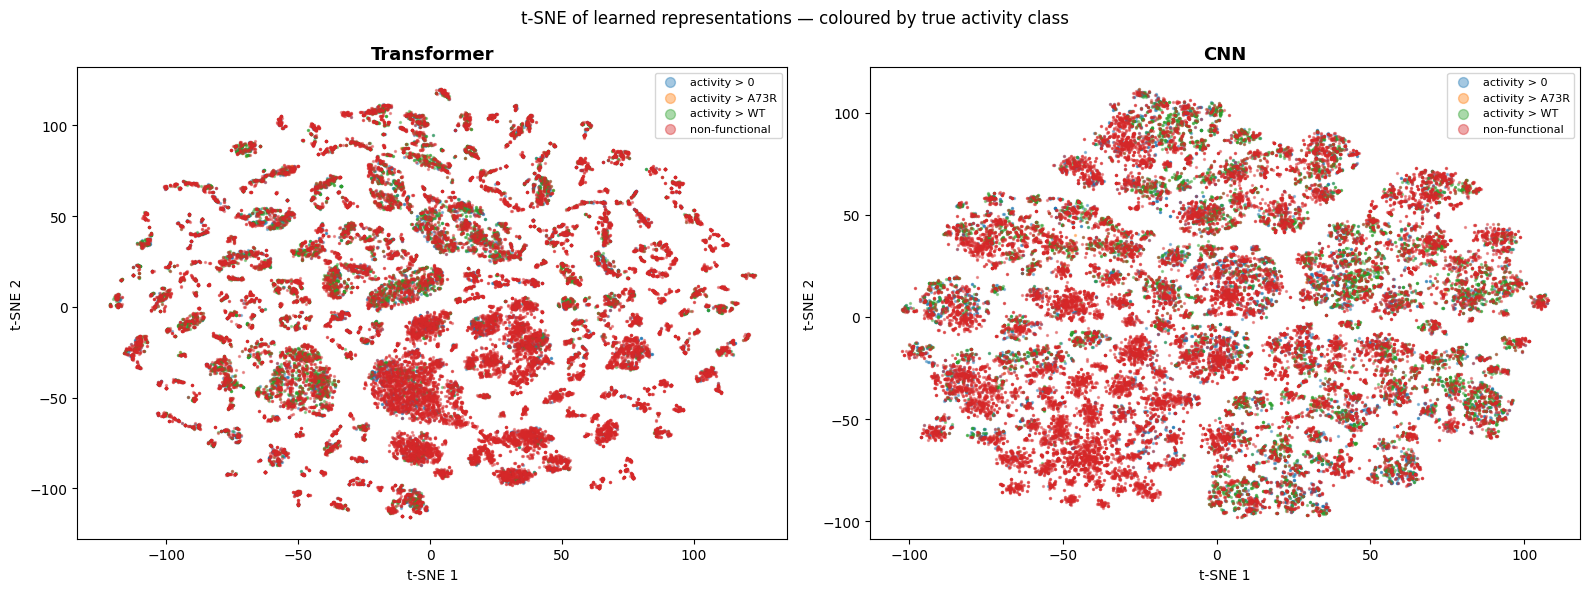

In [ ]:
# t-SNE of learned representations
# will take a while to run on CPU

BATCH_SIZE = 512

def extract_embeddings(model, sequences, batch_size=BATCH_SIZE, is_cnn=False):
    """Run sequences through model in batches, return (N, d) embedding matrix."""
    all_embs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_seqs = sequences[i : i + batch_size]
            tokens = torch.tensor(
                [tokenize(s) for s in batch_seqs], dtype=torch.long
            )
            _, emb = model(tokens, return_embeddings=True)
            all_embs.append(emb.numpy())
    return np.concatenate(all_embs, axis=0)

# Load models
model_trans, _ = load_checkpoint('checkpoints/training_trans/epoch_046_acc0.6746.pt')
model_cnn,   _ = cnn_load_checkpoint('checkpoints/training_cnn/epoch_023_acc0.6700.pt')

seqs       = trans_preds_df["sequence"].tolist()   # same test split for both
true_labels = trans_preds_df["activity_level"].tolist()

print("Extracting transformer embeddings…")
emb_trans = extract_embeddings(model_trans, seqs)   # (N, 128)
print("Extracting CNN embeddings…")
emb_cnn   = extract_embeddings(model_cnn,   seqs, is_cnn=True)  # (N, 4544)

# PCA → 50 dims before t-SNE (standard practice; especially helpful for CNN's large space)
print("Running PCA + t-SNE…")
pca_trans = PCA(n_components=50, random_state=42).fit_transform(emb_trans)
pca_cnn   = PCA(n_components=50, random_state=42).fit_transform(emb_cnn)

tsne       = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
tsne_trans = tsne.fit_transform(pca_trans)
tsne_cnn   = tsne.fit_transform(pca_cnn)


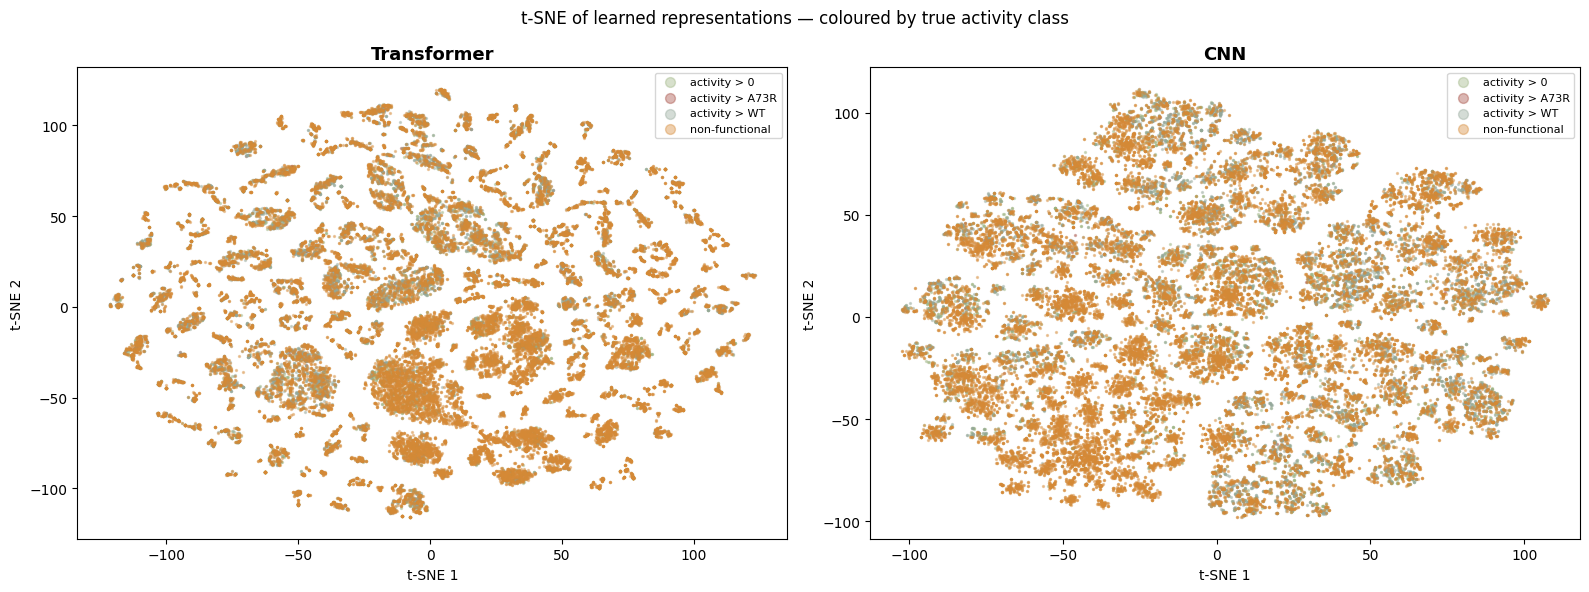

In [10]:
# Plot
CLASS_COLORS = {
    'activity > A73R': '#A44A3F',
    'activity > WT':   '#94A89A',
    'activity > 0':    '#9CB380',
    'non-functional':  '#D58936',
}

#CLASS_COLORS = {cls: f"C{i}" for i, cls in enumerate(ACTIVITY_CLASSES)}


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, coords) in zip(axes, [("Transformer", tsne_trans), ("CNN", tsne_cnn)]):
    for cls in ACTIVITY_CLASSES:
        mask = np.array(true_labels) == cls
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=CLASS_COLORS[cls], label=cls,
            s=2, alpha=0.4, rasterized=True,
        )
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(markerscale=5, fontsize=8, loc="best")

fig.suptitle("t-SNE of learned representations — coloured by true activity class", fontsize=12)
plt.tight_layout()
plt.show()

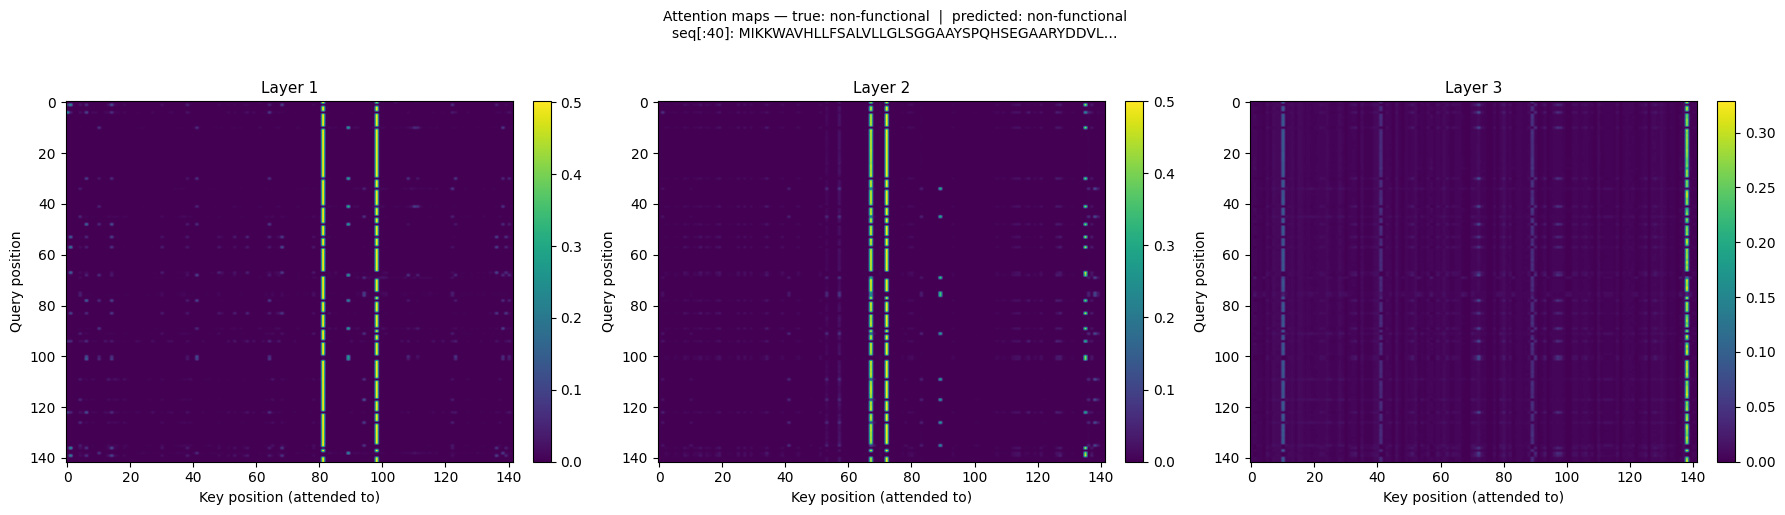

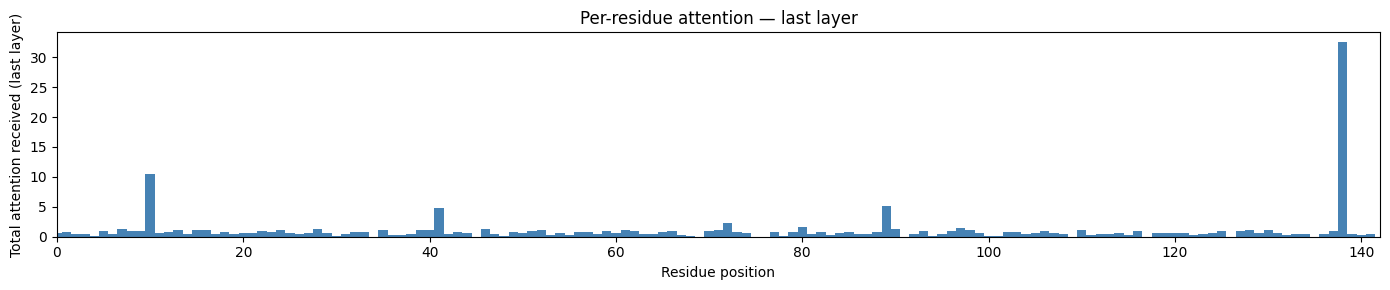

In [ ]:
# attention maps to show which residue positions the transformer attends to most strongly.

# Load transformer checkpoint (needed for attention weights — not in saved CSV)
model_trans, _ = load_checkpoint('checkpoints/training_trans/epoch_046_acc0.6746.pt')
model_trans.eval()

# Pick one sequence — change the index to explore different variants
sample = trans_preds_df.iloc[0]
tokens = torch.tensor([tokenize(sample["sequence"])], dtype=torch.long)  # (1, seq_len)

with torch.no_grad():
    _, attn_list = model_trans(tokens, return_attention=True)
# attn_list: one (1, seq_len, seq_len) per layer, averaged over heads by nn.MultiheadAttention

seq_len  = tokens.shape[1]
n_layers = len(attn_list)

# --- per-layer attention maps ---
fig, axes = plt.subplots(1, n_layers, figsize=(6 * n_layers, 5))
if n_layers == 1:
    axes = [axes]

for ax, (layer_idx, attn) in zip(axes, enumerate(attn_list)):
    weights = attn[0].numpy()  # (seq_len, seq_len)
    im = ax.imshow(weights, cmap="viridis", aspect="auto")
    ax.set_title(f"Layer {layer_idx + 1}", fontsize=11)
    ax.set_xlabel("Key position (attended to)")
    ax.set_ylabel("Query position")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

true_cls = sample["activity_level"]
pred_cls = sample["predicted_class"]
fig.suptitle(
    f"Attention maps — true: {true_cls}  |  predicted: {pred_cls}\n"
    f"seq[:40]: {sample['sequence'][:40]}…",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.show()

# --- per-residue importance: column-sum of last layer ---
last_layer     = attn_list[-1][0].numpy()       # (seq_len, seq_len)
pos_importance = last_layer.sum(axis=0)         # total attention received per position

fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.bar(range(seq_len), pos_importance, color="steelblue", width=1.0)
ax2.set_xlabel("Residue position")
ax2.set_ylabel("Total attention received (last layer)")
ax2.set_title("Per-residue attention — last layer")
ax2.set_xlim(0, seq_len)
plt.tight_layout()
plt.show()

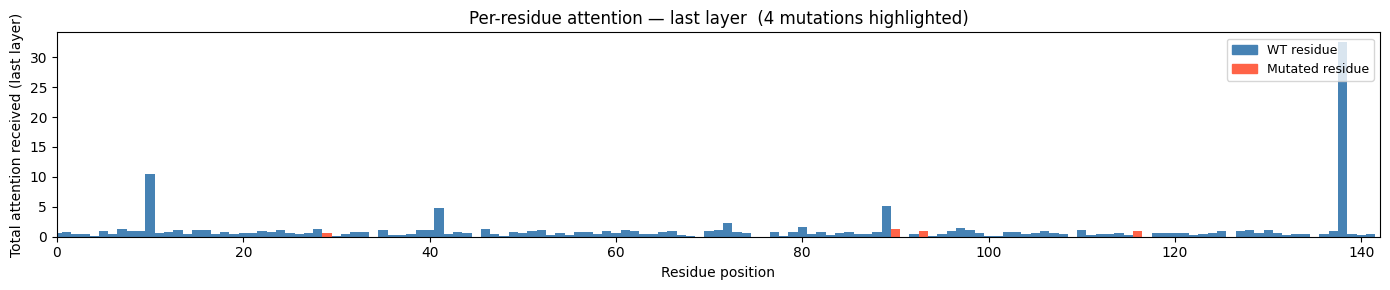

In [31]:
# attention maps to show which residue positions the transformer attends to most strongly.

# Load transformer checkpoint (needed for attention weights — not in saved CSV)
model_trans, _ = load_checkpoint('checkpoints/training_trans/epoch_046_acc0.6746.pt')
model_trans.eval()

# Pick one sequence — change the index to explore different variants
sample = trans_preds_df.iloc[0]
tokens = torch.tensor([tokenize(sample["sequence"])], dtype=torch.long)  # (1, seq_len)

with torch.no_grad():
    _, attn_list = model_trans(tokens, return_attention=True)
# attn_list: one (1, seq_len, seq_len) per layer, averaged over heads by nn.MultiheadAttention

seq_len  = tokens.shape[1]
n_layers = len(attn_list)

# --- per-residue importance: column-sum of last layer ---
import ast

# parse mutated positions (1-indexed in mutations col → 0-indexed for bar chart)
muts = ast.literal_eval(sample["mutations"])
mut_positions = {pos - 1 for _, pos, _ in muts}

bar_colors = ["tomato" if i in mut_positions else "steelblue" for i in range(seq_len)]

fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.bar(range(seq_len), pos_importance, color=bar_colors, width=1.0)
ax2.set_xlabel("Residue position")
ax2.set_ylabel("Total attention received (last layer)")
ax2.set_title(
    f"Per-residue attention — last layer  "
    f"({len(mut_positions)} mutation{'s' if len(mut_positions) != 1 else ''} highlighted)"
)
ax2.set_xlim(0, seq_len)

from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color="steelblue", label="WT residue"),
    Patch(color="tomato",    label="Mutated residue"),
], loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


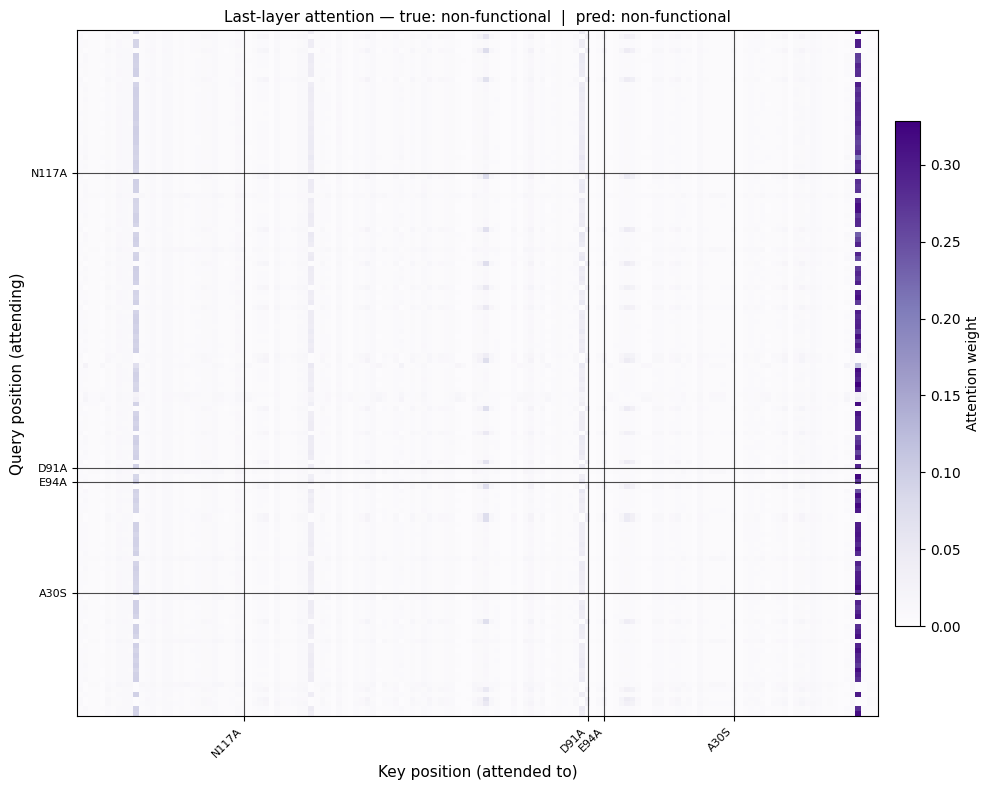

In [38]:
# single sequence attention map with mutation positions marked on axes
import ast
import matplotlib.ticker as ticker

muts = ast.literal_eval(sample["mutations"])
mut_positions = {pos - 1 for _, pos, _ in muts}   # 0-indexed
mut_labels    = {pos - 1: f"{o}{pos}{n}" for o, pos, n in muts}

last_layer = attn_list[-1][0].numpy()   # (seq_len, seq_len)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(last_layer, cmap="Purples", aspect="auto", interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Attention weight")

ax.set_xlabel("Key position (attended to)", fontsize=11)
ax.set_ylabel("Query position (attending)", fontsize=11)
ax.set_title(
    f"Last-layer attention — true: {sample['activity_level']}  |  pred: {sample['predicted_class']}",
    fontsize=11,
)

# mark mutation positions on both axes with red lines and labels
for pos in mut_positions:
    ax.axvline(pos, color="black", linewidth=0.8, alpha=0.7)
    ax.axhline(pos, color="black", linewidth=0.8, alpha=0.7)

# tick labels only at mutation positions
ax.set_xticks(list(mut_positions))
ax.set_xticklabels([mut_labels[p] for p in sorted(mut_positions)],
                   rotation=45, ha="right", fontsize=8, color="black")
ax.set_yticks(list(mut_positions))
ax.set_yticklabels([mut_labels[p] for p in sorted(mut_positions)],
                   fontsize=8, color="black")

plt.tight_layout()
plt.show()


In [ ]:
# pulling out attn weights for plotting heat maps
# takes about 1.5 min to run on CPU
def extract_attention_weights(model, sequences, batch_size=BATCH_SIZE):
    """Return last-layer attention for every sequence. Shape: (N, seq_len, seq_len)."""
    all_attn = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_seqs = sequences[i : i + batch_size]
            tokens = torch.tensor(
                [tokenize(s) for s in batch_seqs], dtype=torch.long
            )
            _, attn_list = model(tokens, return_attention=True)
            all_attn.append(attn_list[-1].numpy())   # (batch, seq_len, seq_len)
    return np.concatenate(all_attn, axis=0)          # (N, seq_len, seq_len)


print("Extracting attention weights for all test sequences…")
attn_all  = extract_attention_weights(model_trans, seqs)   # (N, seq_len, seq_len)
mean_attn = attn_all.mean(axis=0)                          # (seq_len, seq_len)


Extracting attention weights for all test sequences…


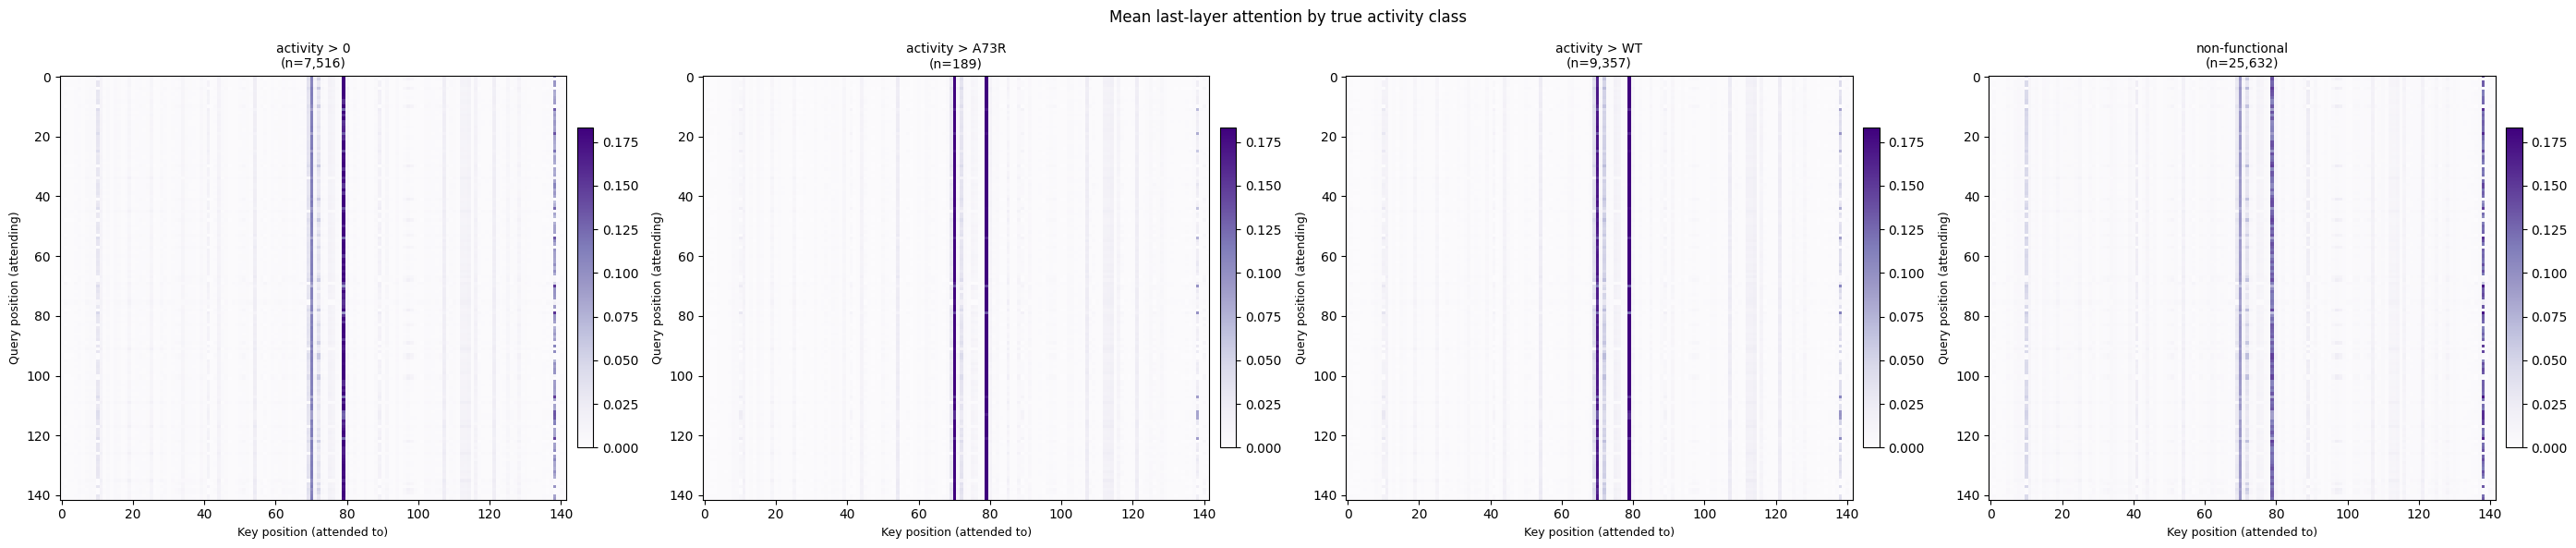

In [35]:
# plotting activity class avg'd attention maps
fig, axes = plt.subplots(1, len(ACTIVITY_CLASSES), figsize=(7 * len(ACTIVITY_CLASSES), 6))

for ax, cls in zip(axes, ACTIVITY_CLASSES):
    mask      = np.array(true_labels) == cls
    cls_mean  = attn_all[mask].mean(axis=0)   # (seq_len, seq_len)

    im = ax.imshow(cls_mean, cmap="Purples", aspect="auto",
                   interpolation="nearest", vmin=0, vmax=mean_attn.max())
    ax.set_title(f"{cls}\n(n={mask.sum():,})", fontsize=10)
    ax.set_xlabel("Key position (attended to)", fontsize=9)
    ax.set_ylabel("Query position (attending)", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

fig.suptitle("Mean last-layer attention by true activity class", fontsize=12)
plt.tight_layout()
plt.show()


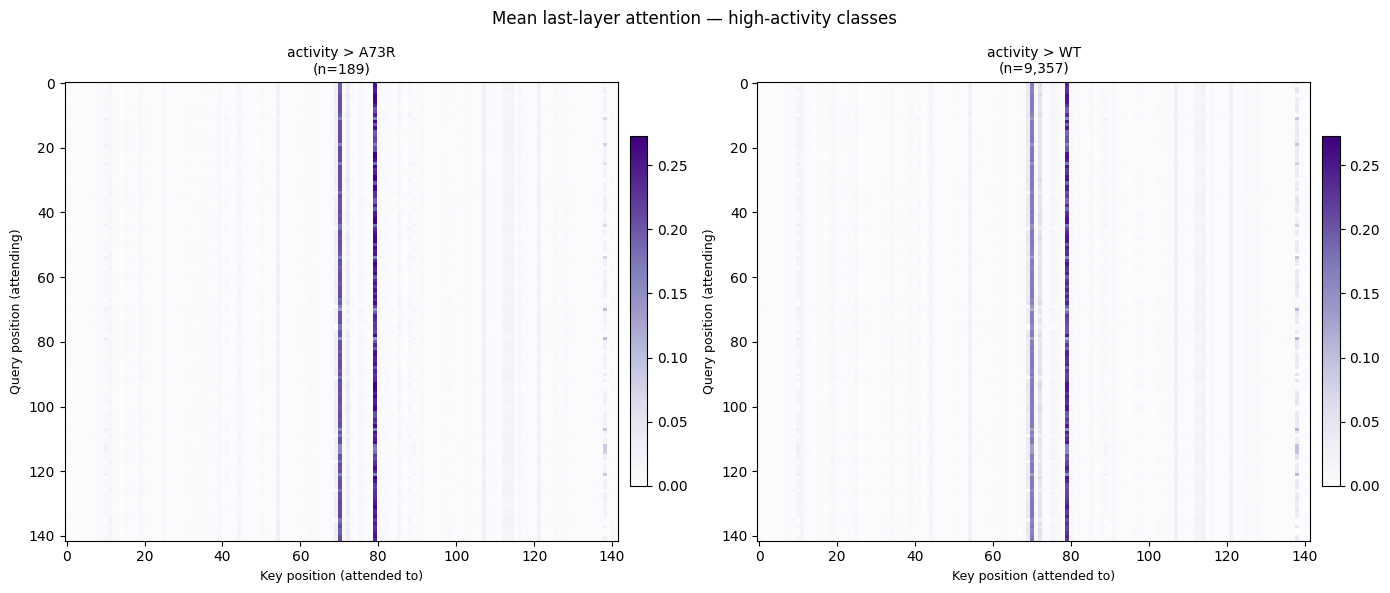


  activity > A73R  (n=189) — top-4 key positions
  #1  pos   80  AA=S  importance=33.0000
  #2  pos   71  AA=S  importance=28.1565  [S71A, mutated in 1% of class]
  #3  pos   73  AA=A  importance=4.5898  [A73I, mutated in 24% of class]
  #4  pos   70  AA=R  importance=3.6980

  activity > WT  (n=9,357) — top-4 key positions
  #1  pos   80  AA=S  importance=30.8132
  #2  pos   71  AA=S  importance=23.2946  [S71D, mutated in 2% of class]
  #3  pos   73  AA=A  importance=7.1695  [A73S, mutated in 24% of class]
  #4  pos   70  AA=R  importance=5.2003


In [37]:
import ast
from collections import Counter

CLASSES_TO_PLOT = ['activity > A73R', 'activity > WT']

# --- heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmax = max(
    attn_all[np.array(true_labels) == cls].mean(axis=0).max()
    for cls in CLASSES_TO_PLOT
)

for ax, cls in zip(axes, CLASSES_TO_PLOT):
    mask     = np.array(true_labels) == cls
    cls_mean = attn_all[mask].mean(axis=0)        # (seq_len, seq_len)

    im = ax.imshow(cls_mean, cmap="Purples", aspect="auto",
                   interpolation="nearest", vmin=0, vmax=vmax)
    ax.set_title(f"{cls}\n(n={mask.sum():,})", fontsize=10)
    ax.set_xlabel("Key position (attended to)", fontsize=9)
    ax.set_ylabel("Query position (attending)", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

fig.suptitle("Mean last-layer attention — high-activity classes", fontsize=12)
plt.tight_layout()
plt.show()

# --- top-4 key positions ---
for cls in CLASSES_TO_PLOT:
    mask     = np.array(true_labels) == cls
    cls_mean = attn_all[mask].mean(axis=0)        # (seq_len, seq_len)
    cls_df   = trans_preds_df[mask].reset_index(drop=True)
    cls_seqs = [seqs[i] for i in np.where(mask)[0]]

    key_importance = cls_mean.sum(axis=0)         # sum over query → (seq_len,)
    top4_idx       = np.argsort(-key_importance)[:4]

    # mutation frequency per position within this class
    mut_freq = Counter(
        pos - 1
        for row in cls_df["mutations"]
        for _, pos, _ in ast.literal_eval(row)
    )
    # most common mutation label at each position (e.g. "A30S")
    mut_labels_at = {}
    for row in cls_df["mutations"]:
        for orig, pos, new in ast.literal_eval(row):
            mut_labels_at.setdefault(pos - 1, Counter())[f"{orig}{pos}{new}"] += 1

    print(f"\n{'='*52}")
    print(f"  {cls}  (n={mask.sum():,}) — top-4 key positions")
    print(f"{'='*52}")
    for rank, pos in enumerate(top4_idx, 1):
        consensus_aa = Counter(s[pos] for s in cls_seqs).most_common(1)[0][0]
        freq         = mut_freq.get(pos, 0) / mask.sum()
        if freq > 0.01:
            top_mut = mut_labels_at[pos].most_common(1)[0][0]
            note    = f"  [{top_mut}, mutated in {freq:.0%} of class]"
        else:
            note = ""
        print(f"  #{rank}  pos {pos+1:>4}  AA={consensus_aa}"
              f"  importance={key_importance[pos]:.4f}{note}")
